# GutBrain 2026 CLEF Task 6


## Structure

Structure: The data folder is split into Articles and Annontations.
- The Annotation folder contains one file and two, where the file constits of the URI with links to the different medical concepts within the dataset, and the folders are split into Train and Dev with the contents of those files having mostly the same structure. The **Train** folder is further split up into "bronze_quality", "silver_quality", and "gold_quality" each containing data of the noted quality. The **Annotation** folder on the other hand contain the data files. The data in the files is structered in the following way:
    - Each datapoint is annotated with the PMID for the publication. Followed by "metadata", which hold the following information: "title", "author", "journal", "year", "abstract", and "annotator"
    - For each datapoint there is also a list of "entities" containing the following information: "start_idx", "end_idx, "location", "text_span", "label", and "uri"´
    - For each datapoint there is also a list of "relations" containing the following information: "subject_start_dix", "subject_end_idx", "subject_location", " subject_text_span", "subject_uri", "predicate", and each subject data is repeated for the object like "object_start_idx"
- The **Articles** folder contain information about the articles as described by the PMID and metadata as in the **Annotation** folder

# EDA

## Intial setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dev_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Dev/json_format/dev.json")
train_gold_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Train/gold_quality/json_format/train_gold.json")
train_silver_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Train/silver_quality/json_format/train_silver.json")
train_silver2025_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Train/silver_quality/json_format/train_silver_2025.json") 
train_bronze_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Train/bronze_quality/json_format/train_bronze.json")

dev_df = dev_df.transpose()
train_df = pd.concat([train_gold_df, train_silver2025_df, train_silver_df, train_bronze_df], axis=1)
train_df = train_df.transpose()

In [4]:
train_df.head()

,metadata,entities,relations,mention_level_relations,concept_level_relations
38860943,{'title': 'Probiotics and microbial metabolite...,"[{'start_idx': 0, 'end_idx': 9, 'location': 't...","[{'subject_start_idx': 0, 'subject_end_idx': 2...","[{'subject_text_span': 'α-SMA', 'subject_label...",[{'subject_uri': 'http://purl.obolibrary.org/o...
37074710,{'title': 'Interplay of Metabolome and Gut Mic...,"[{'start_idx': 13, 'end_idx': 22, 'location': ...","[{'subject_start_idx': 178, 'subject_end_idx':...","[{'subject_text_span': 'Bacteroidota', 'subjec...",[{'subject_uri': 'http://purl.obolibrary.org/o...
36093178,{'title': 'A comparison of the composition and...,"[{'start_idx': 53, 'end_idx': 76, 'location': ...","[{'subject_start_idx': 53, 'subject_end_idx': ...",[{'subject_text_span': 'oral and gut microbiot...,[{'subject_uri': 'http://purl.obolibrary.org/o...
35328673,{'title': 'The Inflammatory Conspiracy in Mult...,"[{'start_idx': 31, 'end_idx': 48, 'location': ...","[{'subject_start_idx': 31, 'subject_end_idx': ...","[{'subject_text_span': 'Multiple Sclerosis', '...",[{'subject_uri': 'http://purl.obolibrary.org/o...
40258729,{'title': 'Characterization of the gut microbi...,"[{'start_idx': 24, 'end_idx': 37, 'location': ...","[{'subject_start_idx': 0, 'subject_end_idx': 1...","[{'subject_text_span': 'AD', 'subject_label': ...",[{'subject_uri': 'http://purl.obolibrary.org/o...


In [5]:
def expand_nested_column(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    """Takes as input a dataframe and column name, where the values of the column are list containing dicts of nested data.
        Returns a new dataframe where each nested value is its own entry"""
    temp_df = df[column_name].to_frame(column_name)
    temp_df = temp_df.explode(column=column_name).dropna(axis=0) # drops NAN, which happens when the list is empty
    temp_df = pd.json_normalize(temp_df[column_name])
    return temp_df

In [6]:
train_entities_df = expand_nested_column(train_df, "entities")
train_relations_df = expand_nested_column(train_df, "relations")

dev_entities_df = expand_nested_column(dev_df, "entities")
dev_relations_df = expand_nested_column(dev_df, "relations")

## Exploration

Things to explore:
- If the text_span present in the Dev set is also present in the Train set. Do the same for relations with predicate
- Relationship between the number of entities and relationships in an article.
- Maybe design something to validate relations with using the subject/object
- For entities and relationships make sure that those with the same text_span maps to the same uri. Remeber to check first if there exist more than one mention of that text_span. If possible consider acronyms

### Text_span present in DEv also present in Train.

In [7]:
# Done for entities
values = dev_entities_df["text_span"].values
unique_values = pd.unique(train_entities_df["text_span"])
not_present = []
for value in values:
    if value not in unique_values:
        not_present.append(value)
        #print(f"{value} from Dev set not present in Train set. This may cause problems")
print(f"{len(not_present)} out of {dev_entities_df.shape[0]} text_spans not found in Train set")

652 out of 2521 text_spans not found in Train set


In [8]:
# Done for relations
values = dev_relations_df["predicate"].values
unique_values = pd.unique(train_relations_df["predicate"])
not_present = []
for value in values:
    if value not in unique_values:
        not_present.append(value)
        print(value)
        #print(f"{value} from Dev set not present in Train set. This may cause problems")
print(f"{len(not_present)} out of {dev_entities_df.shape[0]} text_spans not found in Train set")

0 out of 2521 text_spans not found in Train set


### Relationship between number of entities and number of relations

In [9]:
def get_lenght(inp):
    return len(inp)

num_relationships = train_df["relations"].apply(get_lenght)
num_entities = train_df["entities"].apply(get_lenght)

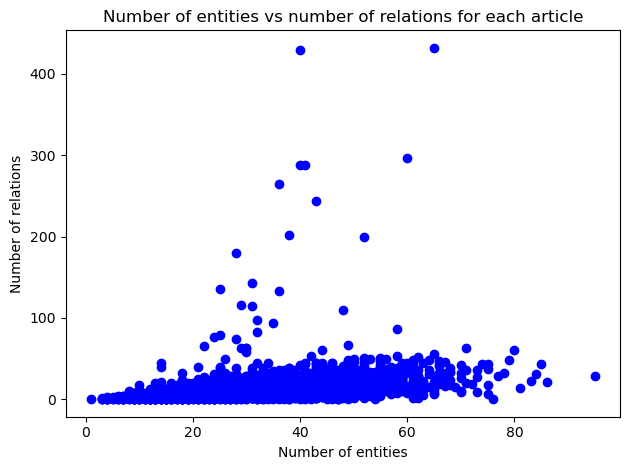

In [10]:
fig, ax = plt.subplots()
ax.plot(num_entities, num_relationships, "bo")
ax.set_ylabel("Number of relations")
ax.set_xlabel("Number of entities")
ax.set_title("Number of entities vs number of relations for each article")
fig.tight_layout()
plt.show()

### Validate relations
This is done using the Annotation guidelines pdf

In [11]:
def is_allowed(inp):
    allowed_relation = {"DDF": {"strike": ["anatomical location"],
                            "change abundance": ["bacteria", "microbiome"],
                            "interact": ["chemical"],
                            "is a": ["DDF"],
                            "affect": ["DDF"],
                            "target": ["human", "animal"]},
                    "chemical": {"located in": ["anatomical location", "human", "animal"],
                                 "interact": ["chemical"],
                                 "part of": ["chemical"],
                                 "impact": ["bacteria", "microbiome"],
                                 "produced by": ["microbiome"],
                                 "influence": ["DDF"],
                                 "change expression": ["gene"],
                                 "administered": ["human", "animal"]},
                    "anatomical location": {"located in": ["human", "animal"]},
                    "bacteria": {"interact": ["bacteria", "chemical", "drug"],
                                 "influence": ["DDF"],
                                 "change expression": ["gene"],
                                 "located in": ["human", "animal"],
                                 "part of": ["microbiome"]},
                    "dietary supplement": {"impact": ["bacteria", "microbiome"],
                                            "influence": ["DDF"],
                                            "change expression": ["gene"],
                                            "administered": ["human", "animal"]},
                    "microbiome": {"used by": ["biomedical technique"],
                                   "located in": ["anatomical location", "human", "animal"],
                                   "change expression": ["gene"],
                                   "is linked to": ["DDF"],
                                   "compared to": ["microbiome"]},
                    "food": {"impact": ["bacteria", "microbiome"],
                             "influence": ["DDF"],
                             "change expression": ["gene"],
                             "administered": ["human", "animal"]},
                    "drug": {"impact": ["bacteria", "microbiome"],
                             "change expression": ["gene"],
                             "administered": ["human", "animal"],
                             "interact": ["chemical", "drug"],
                             "change effect": ["DDF"]},
                    "animal": {"used by": ["biomedical technique"]},
                    "human": {"used by": ["biomedical technique"]}
    }
    subject_label = inp["subject_label"]
    object_label = inp["object_label"]
    predicate = inp["predicate"]
    try:
        allowed_objects = allowed_relation[subject_label][predicate]
    except:
        return False
    return object_label in allowed_objects

In [12]:
train_relations_df.apply(is_allowed, axis=1).value_counts()

True    59771
Name: count, dtype: int64

### Check that no text_span is mapped to different URI

In [13]:
validate_df = train_entities_df[["text_span", "uri"]]
validate_df = validate_df.drop_duplicates()
result = (validate_df.value_counts() > 1).value_counts()
result

count
False    39967
Name: count, dtype: int64

# Experimentations

The data needed for NER should be in the format ("text", {"entities": ["start", "end", "label"], ...}) or ("text", "start", "end", "label"). Alternatively it could also be another similar format that allow for each iteration of each pair of text and entity. The different notations means:
- "text" refers to the text that is feed into the model to get the entities. In our case text is either the abstract or the title.
- "start" is the start index for an entity within the text.
- "end" is the end index for an entity within the text.
- "label" refers to the label of the entity witin the span start to end.

## Option 1

In [14]:
dev_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Dev/json_format/dev.json", orient="index")
dev_df = dev_df[["metadata", "entities"]]

In [15]:
metadata_df = pd.json_normalize(dev_df["metadata"])
metadata_df = metadata_df.drop(["author", "journal", "year"], axis=1)
expanded = expand_nested_column(dev_df, "entities")
full_df = pd.merge(metadata_df, expanded, how="inner", left_index=True, right_index=True)
mask = full_df["location"] == "title"
full_df = full_df.groupby(mask)

In [16]:
def collapse_df(df: pd.DataFrame, text_column: str):
    information = dict()
    for index, row in df.iterrows():
        entity = (row["start_idx"], row["end_idx"], row["label"])
        if index not in information.keys():
            information[index] = {"text": row[text_column], "entities": [entity]}
        else:
            information[index]["entities"].append(entity)
    df = pd.DataFrame(information)
    return df.T

In [17]:
options = list(expanded["location"].unique())
full_df = pd.concat([collapse_df(full_df.get_group(i), options[i]) for i in range(full_df.ngroups)], axis=0)

In [18]:
full_df

,text,entities
35766370,Orthopedic Surgery Causes Gut Microbiome Dysbi...,"[(15, 28, microbiome), (98, 113, human), (127,..."
34912029,Cadmium exposure modulates the gut-liver axis ...,"[(4, 42, gene), (91, 109, DDF), (112, 113, DDF..."
40791596,Exploring the mycobiota in multiple sclerosis:...,"[(0, 17, DDF), (20, 21, DDF), (29, 60, DDF), (..."
40376196,Potential benefits of kefir and its compounds ...,"[(0, 18, DDF), (62, 80, DDF), (89, 93, anatomi..."
36731694,In-depth investigation of the mechanisms of Sc...,"[(0, 19, drug), (22, 33, drug), (84, 102, DDF)..."
...,...,...
33963281,Sleep deprivation (SD) is increasingly common ...,"[(0, 13, microbiome), (29, 49, DDF), (55, 74, ..."
36804535,Patients with depression exhibit reduced bone ...,"[(22, 31, drug), (40, 67, DDF), (72, 87, anima..."
34174901,Minocycline is a clinically available syntheti...,"[(24, 34, drug), (45, 82, DDF), (94, 96, DDF),..."
33327540,"Anxiety disorders comprise persistent, disabli...","[(0, 13, food)]"


## Option 2

In [19]:
dev_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Dev/json_format/dev.json", orient="index")
dev_df = dev_df[["metadata", "entities"]]

In [20]:
metadata_df = pd.json_normalize(dev_df["metadata"])
metadata_df = metadata_df.drop(["author", "journal", "year"], axis=1)
expanded = expand_nested_column(dev_df, "entities")
full_df = pd.merge(metadata_df, expanded, how="inner", left_index=True, right_index=True)
mask = full_df["location"] == "title"
full_df = full_df.groupby(mask)

In [21]:
def get_data(df: pd.DataFrame) -> pd.DataFrame:
    location = df["location"].unique()[0]
    df.rename(columns={location: "text"}, inplace=True)
    return df[["text", "start_idx", "end_idx", "label"]]

In [22]:
full_df = pd.concat([get_data(full_df.get_group(i)) for i in range(full_df.ngroups)])
full_df

,text,start_idx,end_idx,label
35766370,To investigate gut microbiota and intestinal b...,15,28,microbiome
35766370,To investigate gut microbiota and intestinal b...,98,113,human
35766370,To investigate gut microbiota and intestinal b...,127,142,DDF
35766370,To investigate gut microbiota and intestinal b...,145,146,DDF
35766370,To investigate gut microbiota and intestinal b...,216,243,DDF
...,...,...,...,...
34174901,Beyond the lesion site: minocycline augments i...,101,104,animal
34174901,Beyond the lesion site: minocycline augments i...,128,141,microbiome
33327540,Ketogenic Diet: A Dietary Modification as an A...,0,13,food
25940667,"The dormant blood microbiome in chronic, infla...",4,27,microbiome


## Option 3

In [56]:
dev_df = pd.read_json("Data/GutBrainIE_Full_Collection_2026/Annotations/Dev/json_format/dev.json", orient="index")
dev_df = dev_df[["metadata", "entities"]]
metadata_df = pd.json_normalize(dev_df["metadata"])
metadata_df = metadata_df.drop(["author", "journal", "year"], axis=1)

In [57]:
test = pd.merge(metadata_df, dev_df["entities"], left_index=True, right_index=True)
test

,title,abstract,annotator,entities
35766370,Orthopedic Surgery Causes Gut Microbiome Dysbi...,To investigate gut microbiota and intestinal b...,expert_6,"[{'start_idx': 26, 'end_idx': 49, 'location': ..."
34912029,Cadmium exposure modulates the gut-liver axis ...,The human Apolipoprotein E4 (ApoE4) variant is...,expert_6,"[{'start_idx': 4, 'end_idx': 42, 'location': '..."
40791596,Exploring the mycobiota in multiple sclerosis:...,Multiple sclerosis (MS) is a complex immune-me...,expert_6,"[{'start_idx': 14, 'end_idx': 22, 'location': ..."
40376196,Potential benefits of kefir and its compounds ...,"Alzheimer's disease, characterized by the prog...",expert_7,"[{'start_idx': 22, 'end_idx': 26, 'location': ..."
36731694,In-depth investigation of the mechanisms of Sc...,Schisandra chinensis (S. chinensis) is an herb...,expert_7,"[{'start_idx': 44, 'end_idx': 78, 'location': ..."
...,...,...,...,...
33963281,Gut microbiota modulates the inflammatory resp...,Sleep deprivation (SD) is increasingly common ...,expert_6,"[{'start_idx': 0, 'end_idx': 13, 'location': '..."
36804535,Beneficial effects of arketamine on the reduce...,Patients with depression exhibit reduced bone ...,expert_3,"[{'start_idx': 22, 'end_idx': 31, 'location': ..."
34174901,Beyond the lesion site: minocycline augments i...,Minocycline is a clinically available syntheti...,expert_6,"[{'start_idx': 24, 'end_idx': 34, 'location': ..."
33327540,Ketogenic Diet: A Dietary Modification as an A...,"Anxiety disorders comprise persistent, disabli...",expert_5,"[{'start_idx': 0, 'end_idx': 13, 'location': '..."


In [58]:
title_information = dict()
abstract_information = dict()
for index, row in test.iterrows():
    if not isinstance(row["entities"], list):
        continue

    title_entites = []
    abstract_entities = []
    for entity in row["entities"]:
        start_idx, end_idx, label = entity["start_idx"], entity["end_idx"], entity["label"]
        if entity["location"] == "title":
            title_entites.append((start_idx, end_idx + 1, label))
        else:
            abstract_entities.append((start_idx, end_idx + 1, label))
    
    if len(title_entites) != 0:
        title_information[index] = {"text": row["title"], "entities": title_entites}
    
    if len(abstract_entities) != 0:
        abstract_information[index] = {"text": row["abstract"], "entities": abstract_entities}

df_1 = pd.DataFrame(title_information).T
df_2 = pd.DataFrame(abstract_information).T
full_df = pd.concat([df_1, df_2])

In [59]:
full_df.to_numpy()
np.save("train_data", full_df.to_numpy())